# Lazada App Reviews - Sentimental Analysis 
### Data Source:
This notebook uses sentimental analysis on Lazada's app reviews (Google store) from Kaggle:
https://www.kaggle.com/datasets/bwandowando/lazada-app-reviews-from-google-store/data

### Objectives:
- Find out what are the customers' sentiment towards Lazada's app.

#### Data Description:
- Unnamed : Index
- review_text : Customer review
- review_rating : Customer rating ranging from 1-5
- author_id : Customer id
- author_name : Customer name
- author_app_version : App version that customer uses
- review_datetime_utc : Date and Time when customer posted their review
- review_likes : The amount of likes a review has 

## Exploratory Data Analysis (EDA)

In [56]:
# If running on a fresh environment, uncomment the pip installs below.

# !pip install pandas numpy matplotlib seaborn scikit-learn nltk emoji wordcloud langdetect
# !pip install transformers torch --upgrade
# !pip install sentencepiece # required by some multilingual Transformer models
# !pip install --upgrade imbalanced-learn

In [110]:
import sklearn

import os, re, string, random
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Text
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import emoji
from wordcloud import WordCloud

import re
import string

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
import nltk

# Resampling
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from collections import Counter

from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek

# Machine Learning Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from imblearn.pipeline import Pipeline as ImbPipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
import joblib # saving models
from sklearn.neighbors import NearestNeighbors

# Machine Learning Validation
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

import warnings
warnings.filterwarnings("ignore")

# Ensure NLTK assets
try:
    _ = stopwords.words("english")
except LookupError:
    nltk.download("stopwords")
try:
    _ = nltk.data.find("tokenizers/punkt")
except LookupError:
    nltk.download("punkt")
try:
    _ = nltk.data.find("sentiment/vader_lexicon.zip")
except LookupError:
    nltk.download("vader_lexicon")
    
nltk.download('punkt_tab')

sns.set_theme()
plt.rcParams["figure.dpi"] = 120

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\alsto\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [58]:
# loading dataset
df = pd.read_csv("LAZADA_REVIEWS.csv")

In [59]:
df.head()

,Unnamed: 0,review_text,review_rating,author_id,author_name,author_app_version,review_datetime_utc,review_likes
0,0,This app is a big step in right direction - gr...,5,109329*********902682,A Google user,1.0,2013-06-09T08:34:37.000Z,2
1,1,This is what I have been looking for. Now I ca...,5,109886*********190000,A Google user,1.0,2013-06-09T09:29:25.000Z,0
2,2,Its a great way of shopping online. But please...,1,114358*********899063,A Google user,1.0,2013-06-09T10:19:39.000Z,0
3,3,Thanks lazada for this app!!,5,108006*********600292,A Google user,1.0,2013-06-10T02:24:14.000Z,0
4,4,Good app ;),5,110676*********237626,A Google user,1.0,2013-06-10T02:35:53.000Z,0


In [60]:
df.shape

(775323, 8)

In [61]:
df.columns

Index(['Unnamed: 0', 'review_text', 'review_rating', 'author_id',
       'author_name', 'author_app_version', 'review_datetime_utc',
       'review_likes'],
      dtype='object')

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 775323 entries, 0 to 775322
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Unnamed: 0           775323 non-null  int64 
 1   review_text          775018 non-null  object
 2   review_rating        775323 non-null  int64 
 3   author_id            775195 non-null  object
 4   author_name          775322 non-null  object
 5   author_app_version   600912 non-null  object
 6   review_datetime_utc  775323 non-null  object
 7   review_likes         775323 non-null  int64 
dtypes: int64(3), object(5)
memory usage: 47.3+ MB


### **Follow up actions:**
- Split up the dataset into training and testing dataset so there isn't a data leakage.
- Are there authors who has too many comments over the others such that it can cause biasness in the app review?
- review_text needs to convert to string dtype
- review_rating will split into sentiment categories, 'positive', 'negative', 'neutral'


In [64]:
df[df['review_text'].duplicated()]

,Unnamed: 0,review_text,review_rating,author_id,author_name,author_app_version,review_datetime_utc,review_likes
67,67,Good,5,117004*********121943,A Google user,1.0.1,2013-06-18T19:18:18.000Z,0
103,103,Great app,5,103579*********094848,A Google user,1.0.2,2013-07-28T13:10:44.000Z,0
115,115,Nice,4,103463*********364007,A Google user,1.0.2,2013-08-19T19:52:10.000Z,0
123,123,Good,5,101472*********807948,A Google user,1.0.2,2013-09-04T14:37:42.000Z,0
132,132,good,4,104615*********588290,A Google user,2.0.1,2013-09-15T02:34:07.000Z,0
...,...,...,...,...,...,...,...,...
775309,775309,very nice,5,102022*********273581,A Google user,7.37.0,2023-11-13T14:19:40.000Z,0
775312,775312,good,5,112571*********852590,A Google user,7.37.0,2023-11-13T14:23:41.000Z,0
775318,775318,nice,5,105611*********908291,A Google user,NaN,2023-11-13T14:35:46.000Z,0
775319,775319,Nice,5,108460*********801893,A Google user,7.37.0,2023-11-13T14:39:25.000Z,0


In [65]:
df.isna().sum()

Unnamed: 0                  0
review_text               305
review_rating               0
author_id                 128
author_name                 1
author_app_version     174411
review_datetime_utc         0
review_likes                0
dtype: int64

There are **duplicated** values in the review_text but it will be kept because the duplicated values are still needed for sentiment analysis and will not affect biasness.

There are also **missing** values in the dataset. Since we will only be looking at review_text and review_rating, we will drop all the null values in review_text since there are only afew of them.

In [67]:
df['author_id'].value_counts().sort_values(ascending=False)

author_id
106224*********970971    2
108251*********386038    2
115385*********904547    2
104626*********394665    2
101496*********456412    2
                        ..
114756*********724527    1
107455*********192107    1
107886*********152196    1
109467*********187285    1
104025*********727802    1
Name: count, Length: 775103, dtype: int64

The most a customer commented was **2 comments** so we do not have to worry about a single customer making too many reviews which causes bias opinions towards the app.

In [69]:
# rating will be our dependent variable so we will need to classify them under positive, negative or neutral
    
def addSentiment(df):
    def rating_to_sentiment(r):
        if r >= 4: 
            return 'positive'
        elif r <= 2: 
            return 'negative'
        else: 
            return 'neutral'
    
    df['sentiment'] = df['review_rating'].apply(rating_to_sentiment)
    return df

addSentiment(df)
df.head()

,Unnamed: 0,review_text,review_rating,author_id,author_name,author_app_version,review_datetime_utc,review_likes,sentiment
0,0,This app is a big step in right direction - gr...,5,109329*********902682,A Google user,1.0,2013-06-09T08:34:37.000Z,2,positive
1,1,This is what I have been looking for. Now I ca...,5,109886*********190000,A Google user,1.0,2013-06-09T09:29:25.000Z,0,positive
2,2,Its a great way of shopping online. But please...,1,114358*********899063,A Google user,1.0,2013-06-09T10:19:39.000Z,0,negative
3,3,Thanks lazada for this app!!,5,108006*********600292,A Google user,1.0,2013-06-10T02:24:14.000Z,0,positive
4,4,Good app ;),5,110676*********237626,A Google user,1.0,2013-06-10T02:35:53.000Z,0,positive


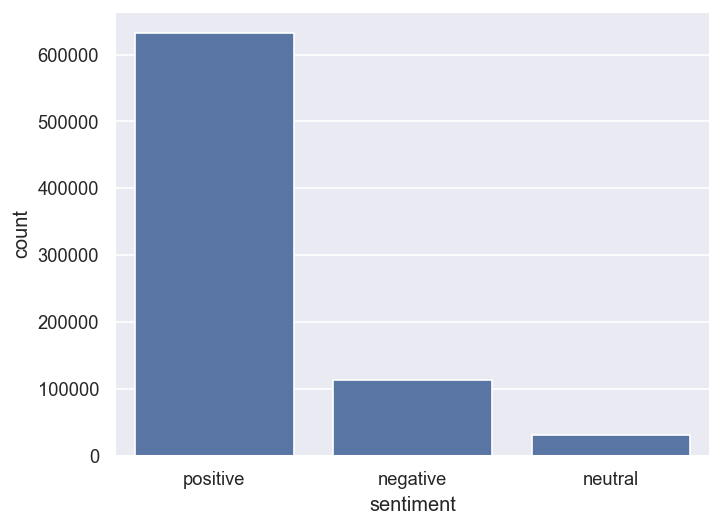

In [70]:
sns.countplot(x='sentiment', data=df)
plt.show()

##### Graph summary
There is a huge imbalance in the classification of sentiments. 'Positive' is overwhelmingly higher than the rest and neutral is very scarce. Hence, to prevent imbalanced data, resampling will be needed.

In [72]:
# changing data type to string
def change_type(df):
    df['review_text'] = df['review_text'].astype('string')
    return df

change_type(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 775323 entries, 0 to 775322
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Unnamed: 0           775323 non-null  int64 
 1   review_text          775018 non-null  string
 2   review_rating        775323 non-null  int64 
 3   author_id            775195 non-null  object
 4   author_name          775322 non-null  object
 5   author_app_version   600912 non-null  object
 6   review_datetime_utc  775323 non-null  object
 7   review_likes         775323 non-null  int64 
 8   sentiment            775323 non-null  object
dtypes: int64(3), object(5), string(1)
memory usage: 53.2+ MB


In [73]:
# drop null values so we can split them up
def drop_null(df):
    df.dropna(subset=['review_text'], inplace=True)
    return df

drop_null(df)

# creating text_len to split up text into words and counting them
df['text_len'] = df['review_text'].apply(lambda x: len(x.split()))
    
print(df['text_len'].describe())
    
    

count    775018.000000
mean          7.321471
std          12.597606
min           1.000000
25%           1.000000
50%           3.000000
75%           7.000000
max         379.000000
Name: text_len, dtype: float64


In [74]:
df.isna().sum()

Unnamed: 0                  0
review_text                 0
review_rating               0
author_id                 119
author_name                 1
author_app_version     174296
review_datetime_utc         0
review_likes                0
sentiment                   0
text_len                    0
dtype: int64

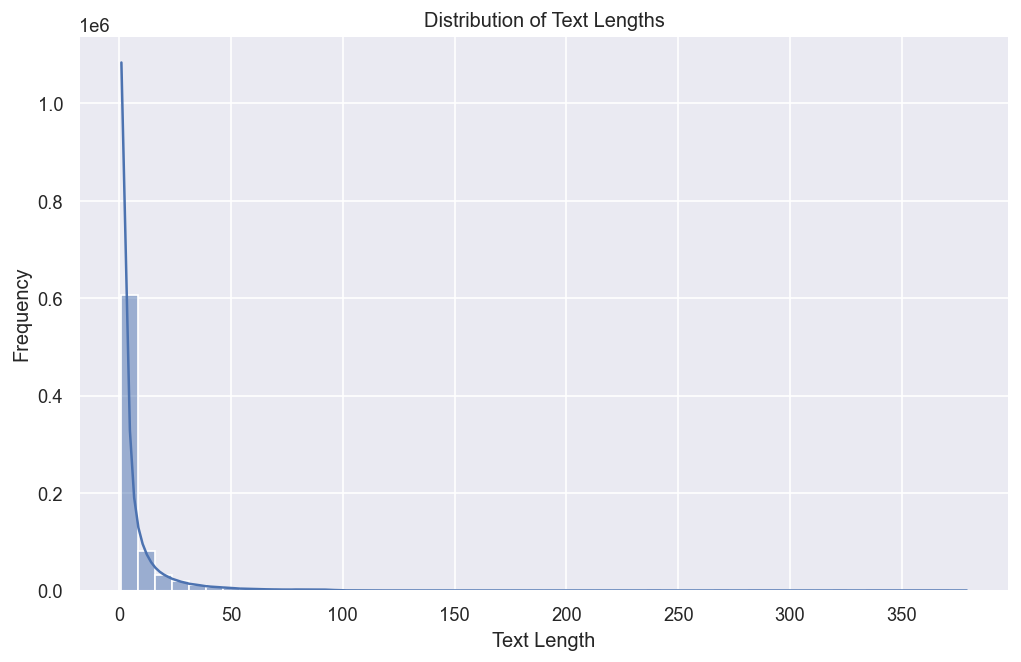

In [75]:
plt.figure(figsize=(10, 6))
sns.histplot(df['text_len'], bins=50, kde=True) 
plt.title('Distribution of Text Lengths')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

##### Summary of graph
Average word count of a text is 7 words. However, there are some texts with high word counts, with the max being 379 words. Long texts can have multiple sentiments to it so it may confuse the model. To counter this, we will do normalisation to analyse the sentiment per sentence/paragraph.

## **EDA Summary**:
- 'sentiment' will be our dependent variable, derived from review_ratings.
- 'review_text' will be used to analze the sentiment.
- There are missing values in review_text which has already been dropped to analyse text lengths.

### Follow up actions:
- Clean text
- Balance classification data using resampling.
- Normalize text length

# Data Preprocessing

In [79]:
df.isna().sum()

Unnamed: 0                  0
review_text                 0
review_rating               0
author_id                 119
author_name                 1
author_app_version     174296
review_datetime_utc         0
review_likes                0
sentiment                   0
text_len                    0
dtype: int64

In [95]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
# stemmer = PorterStemmer()
def clean_text(text):
    text = text.lower() # lower case
    text = re.sub(r'http\S+|www\S+', '', text) # remove URLs
    text = re.sub(r'<.*?>', '', text) # remove HTML tags
    text = re.sub(r'@\w+', '', text)  # remove @mentions
    text = re.sub(r'#\w+', '', text)  # remove #hashtags
    text = re.sub(r'\d+', '', text) # remove numbers e.g. order ID, dates or order numbers
    text = text.translate(str.maketrans('', '', string.punctuation)) # remove punctuations (exclamation marks can indicate emotion, depends on use case)
    text = emoji.demojize(text) # change emoji into text emoji
    text = re.sub(r'(.)\1{2,}', r'\1\1', text) # normalize repeated characters, "goooood" to "good"

    # tokenization
    tokens = nltk.word_tokenize(text) # tokenize sentences into word tokens
    tokens = [w for w in tokens if w not in stop_words] # remove stopwords
    tokens = [lemmatizer.lemmatize(w) for w in tokens] # lemmatization, "running" to "run" to reduce vocab size. Slower than stem to understand deeper text analysis but costs more.
    # tokens = [stemmer.stem(w) for w in tokens] # stemming, either this or lemmatization, not both. Used for speed and scalability (less cost)

    return ' '.join(tokens)
    
def text_preprocessed(df):
    df = addSentiment(df)
    df = change_type(df)
    df = drop_null(df)

    df['clean_text'] = df['review_text'].apply(clean_text)
    
    # only cleaned text and sentiment is needed for this analysis
    return df[['clean_text', 'sentiment']]

df_clean = text_preprocessed(df)
df_clean.head()

,clean_text,sentiment
0,app big step right direction great overview pr...,positive
1,looking buy anything phone product delivered d...,positive
2,great way shopping online please make u choose...,negative
3,thanks lazada app,positive
4,good app,positive


## Summary of Data-Preprocessing

Created functions that can be implemented into pipeline at the end for a seamless workflow.

For reference,
- addSentiment(df)
- text_preprocessed(df)

# Model Training and Evaluation

In [101]:
X = df_clean['clean_text']
y = df_clean['sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_SEED, stratify=y)

### Logistic Regression (Baseline Model)
TF-IDF reflects how important a word is to a document in a collection or corpus, often used to reflect the relevance of words.
Logistic regression is a classification model which is suitable for multiclass sentiment analysis (positive, negative, neutral) and works well with TF-IDF.

In [106]:
# helper: evaluate any fitted pipeline
def evaluate(name, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    print(f"{"="*60}")
    print(f"{name}")
    print(f"{"="*60}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1 Macro: {f1_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1 Weighted: {f1_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"Classification Report: {classification_report(y_test, y_pred)}")
    # confusion matrix heatmap
    cm = confusion_matrix(y_test, y_pred, labels=["positive", "neutral", "negative"])
    fix, ax = plt.subplots(figsize=(6,4))
    disp = ConfusionMatrixDisplay(cm, display_labels=["positive", "neutral", "negative"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name} - Confusion Matrix")
    plt.tight_layout()
    plt.show()
    return y_pred
    

Logistic Regression
Accuracy: 0.7748
F1 Macro: 0.5872
F1 Weighted: 0.8255
Classification Report:               precision    recall  f1-score   support

    negative       0.74      0.71      0.73     33840
     neutral       0.10      0.45      0.16      9045
    positive       0.96      0.80      0.87    189621

    accuracy                           0.77    232506
   macro avg       0.60      0.66      0.59    232506
weighted avg       0.90      0.77      0.83    232506



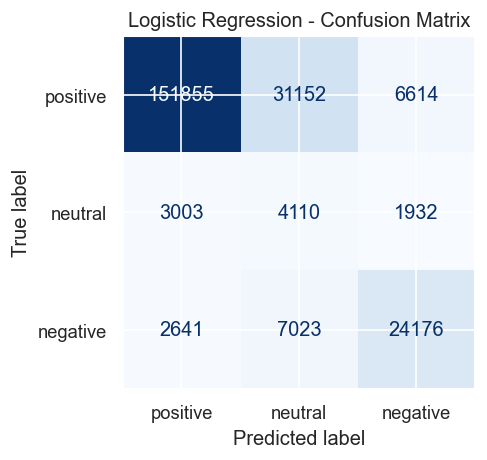

In [112]:
# Create pipeline to prevent data leakage
# class_weight balanced adjusts the importance of each class to help with imbalance
lr_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ('clf', LogisticRegression(C=1, penalty="l2", class_weight='balanced', max_iter=1000, random_state=42))
])
lr_pipe.fit(X_train, y_train)
y_pred_lr = evaluate("Logistic Regression", lr_pipe, X_test, y_test)

In [120]:
# cross validation (more robust, 5-fold CV on training set to get stable F1 estimates
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_validate(
    lr_pipe, X_train, y_train, cv=cv,
    scoring={"f1_macro": "f1_macro", "accuracy": "accuracy"},
    n_jobs=-1
)

In [126]:
print(f"CV Accuracy: {cv_scores['test_accuracy'].mean():.4f} + {cv_scores['test_accuracy'].std():.4f}")
print(f"CV F1 Macro: {cv_scores['test_f1_macro'].mean():.4f} + {cv_scores['test_f1_macro'].std():.4f}")

CV Accuracy: 0.7762 + 0.0018
CV F1 Macro: 0.5885 + 0.0012


In [55]:
# Bundle models into a dictionary
models = {
    "logistic": lr_model,
}

# Save all models to a single file
joblib.dump(models, "all_models.pkl")

# Load the dictionary of models
# loaded_models = joblib.load("all_models.pkl")

# Access individual models
# logistic_model = loaded_models["logistic"]
# do predictions after

['all_models.pkl']

#### Logistic Regression (Baseline Model) Performance
- Accuracy of **0.78**

### Naives Baye Model

Best Parameters: {'clf__alpha': 0.1, 'clf__fit_prior': True}
Naives Bayes (tuned)
Accuracy: 0.8995
F1 Macro: 0.5810
F1 Weighted: 0.8841
Classification Report:               precision    recall  f1-score   support

    negative       0.74      0.77      0.75     33840
     neutral       0.27      0.02      0.04      9045
    positive       0.93      0.96      0.95    189621

    accuracy                           0.90    232506
   macro avg       0.64      0.59      0.58    232506
weighted avg       0.88      0.90      0.88    232506



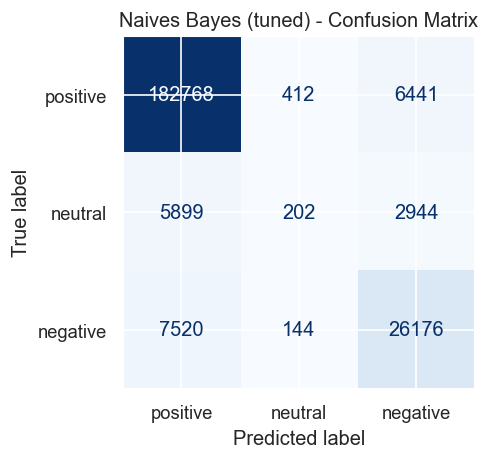

In [130]:
# Naive Bayes model
# if standardscaler was used on dataset, then this model would break silently as it only accepts non-negative features while scaler produces negative features
nb_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ('clf', MultinomialNB())
])

# Hyperparameter grid
param_grid = {
    'clf__alpha': [0.1, 0.5, 1.0, 5.0],      # Laplace smoothing
    'clf__fit_prior': [True, False]          # Use class priors or not
}

# Grid search with 5 fold cross-validation
# Note: f1_macro is used for multiclass (default "f1" is binary only)
gs_nb = GridSearchCV(nb_pipe, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
gs_nb.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", gs_nb.best_params_)

nb_best = gs_nb.best_estimator_
y_pred_nb = evaluate("Naives Bayes (tuned)", nb_best, X_test, y_test)

In [63]:
# Add nb model
# Load existing models
models = joblib.load("all_models.pkl")

# Add new model
models["naives_baye"] = nb_best


# 3. Save back to the same file
joblib.dump(models, "all_models.pkl")


['all_models.pkl']

#### Comparing baseline model against naives baye model
Baseline model had a prediction accuracy of **0.78**, while the naives bayes model had a prediction accuracy of **0.76**. Hence baseline model is still better.


### SVM Model
LinearSVC model will be used instead of SVC model as the SVC model is not optimal for the size of this dataset. I will be using SGDClassifier to track progress and use early stopping with the big dataset in mind.

In [41]:
# # linear SVM model
# linearsvm = LinearSVC(
#     tol=1e-3,       # tolerance for stopping, decrease if needed
#     max_iter=5000,  # increase if there is convergence warnings
#     dual=False      # faster when n_samples > n_features
# )

# # Hyperparameter grid
# param_grid = {
#     'C': [0.01, 0.1, 1, 10, 100],
#     'penalty': ['l2'],   # or add 'l1' if you want sparse solutions
#     'loss': ['squared_hinge', 'hinge']
# }

# # GridSearchCV for hyperparameter tuning

# grid_search = GridSearchCV(linearsvm, param_grid, cv=5, scoring='f1', n_jobs=-1)
# grid_search.fit(X_train_scaled, y_bal)

# # Best param
# print("Best parameters:", grid_search.best_params_)

Best parameters: {'C': 0.01, 'loss': 'squared_hinge', 'penalty': 'l2'}


In [47]:
# linear SVM model
from sklearn.linear_model import SGDClassifier

linearsvm = SGDClassifier(
        loss="hinge",        # hinge loss = linear SVM
        max_iter=1000,
        tol=1e-3,
        verbose=1,           # <-- print progress each epoch
    )

# Hyperparameter grid
param_grid = {
    'alpha': [1e-4, 1e-3, 1e-2],   # like 1/C in SVM
    'penalty': ['l2', 'l1'],
    'learning_rate': ['optimal', 'invscaling'],
}

# GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(linearsvm, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_scaled, y_bal)

# Best param
print("Best parameters:", grid_search.best_params_)

-- Epoch 1
Norm: 95.24, NNZs: 4988, Bias: -2.902053, T: 600000, Avg. loss: 50.993762
Total training time: 0.06 seconds.
-- Epoch 2
Norm: 50.50, NNZs: 4993, Bias: -2.510166, T: 1200000, Avg. loss: 7.284720
Total training time: 0.13 seconds.
-- Epoch 3
Norm: 34.75, NNZs: 4994, Bias: -2.215931, T: 1800000, Avg. loss: 4.408885
Total training time: 0.19 seconds.
-- Epoch 4
Norm: 26.57, NNZs: 4994, Bias: -1.962286, T: 2400000, Avg. loss: 3.225908
Total training time: 0.25 seconds.
-- Epoch 5
Norm: 21.52, NNZs: 4994, Bias: -1.760326, T: 3000000, Avg. loss: 2.553001
Total training time: 0.31 seconds.
-- Epoch 6
Norm: 18.23, NNZs: 4994, Bias: -1.588095, T: 3600000, Avg. loss: 2.153699
Total training time: 0.38 seconds.
-- Epoch 7
Norm: 16.02, NNZs: 4994, Bias: -1.437958, T: 4200000, Avg. loss: 1.866037
Total training time: 0.44 seconds.
-- Epoch 8
Norm: 14.06, NNZs: 4994, Bias: -1.311635, T: 4800000, Avg. loss: 1.661307
Total training time: 0.50 seconds.
-- Epoch 9
Norm: 12.79, NNZs: 4994, Bias

Norm: 2.95, NNZs: 4996, Bias: -1.000036, T: 42000000, Avg. loss: 0.483198
Total training time: 4.50 seconds.
-- Epoch 71
Norm: 2.91, NNZs: 4996, Bias: -0.999960, T: 42600000, Avg. loss: 0.481394
Total training time: 4.57 seconds.
-- Epoch 72
Norm: 2.87, NNZs: 4996, Bias: -0.999996, T: 43200000, Avg. loss: 0.479934
Total training time: 4.64 seconds.
-- Epoch 73
Norm: 2.86, NNZs: 4996, Bias: -1.000023, T: 43800000, Avg. loss: 0.478059
Total training time: 4.70 seconds.
-- Epoch 74
Norm: 2.85, NNZs: 4996, Bias: -0.999989, T: 44400000, Avg. loss: 0.476794
Total training time: 4.77 seconds.
-- Epoch 75
Norm: 2.82, NNZs: 4996, Bias: -0.999985, T: 45000000, Avg. loss: 0.474945
Total training time: 4.84 seconds.
-- Epoch 76
Norm: 2.80, NNZs: 4996, Bias: -1.000016, T: 45600000, Avg. loss: 0.473807
Total training time: 4.90 seconds.
-- Epoch 77
Norm: 2.78, NNZs: 4996, Bias: -0.999987, T: 46200000, Avg. loss: 0.471955
Total training time: 4.97 seconds.
-- Epoch 78
Norm: 2.77, NNZs: 4996, Bias: -0

Norm: 5.75, NNZs: 4997, Bias: 0.983756, T: 14400000, Avg. loss: 1.039532
Total training time: 1.62 seconds.
-- Epoch 25
Norm: 5.61, NNZs: 4997, Bias: 0.980977, T: 15000000, Avg. loss: 1.019746
Total training time: 1.68 seconds.
-- Epoch 26
Norm: 5.45, NNZs: 4997, Bias: 0.978281, T: 15600000, Avg. loss: 1.000165
Total training time: 1.75 seconds.
-- Epoch 27
Norm: 5.33, NNZs: 4997, Bias: 0.974638, T: 16200000, Avg. loss: 0.983038
Total training time: 1.82 seconds.
-- Epoch 28
Norm: 5.21, NNZs: 4997, Bias: 0.970870, T: 16800000, Avg. loss: 0.969831
Total training time: 1.89 seconds.
-- Epoch 29
Norm: 5.09, NNZs: 4997, Bias: 0.968030, T: 17400000, Avg. loss: 0.954424
Total training time: 1.96 seconds.
-- Epoch 30
Norm: 4.97, NNZs: 4997, Bias: 0.963895, T: 18000000, Avg. loss: 0.941365
Total training time: 2.03 seconds.
-- Epoch 31
Norm: 4.90, NNZs: 4997, Bias: 0.961250, T: 18600000, Avg. loss: 0.927482
Total training time: 2.10 seconds.
-- Epoch 32
Norm: 4.81, NNZs: 4997, Bias: 0.957891, 

Norm: 2.94, NNZs: 4997, Bias: 0.859734, T: 56400000, Avg. loss: 0.691267
Total training time: 6.57 seconds.
-- Epoch 95
Norm: 2.93, NNZs: 4997, Bias: 0.859213, T: 57000000, Avg. loss: 0.689823
Total training time: 6.65 seconds.
-- Epoch 96
Norm: 2.92, NNZs: 4997, Bias: 0.858308, T: 57600000, Avg. loss: 0.688235
Total training time: 6.72 seconds.
-- Epoch 97
Norm: 2.91, NNZs: 4997, Bias: 0.857592, T: 58200000, Avg. loss: 0.687002
Total training time: 6.80 seconds.
-- Epoch 98
Norm: 2.90, NNZs: 4997, Bias: 0.856915, T: 58800000, Avg. loss: 0.686115
Total training time: 6.87 seconds.
-- Epoch 99
Norm: 2.89, NNZs: 4997, Bias: 0.856088, T: 59400000, Avg. loss: 0.684900
Total training time: 6.95 seconds.
-- Epoch 100
Norm: 2.89, NNZs: 4997, Bias: 0.855316, T: 60000000, Avg. loss: 0.683862
Total training time: 7.02 seconds.
-- Epoch 101
Norm: 2.88, NNZs: 4997, Bias: 0.854493, T: 60600000, Avg. loss: 0.683416
Total training time: 7.09 seconds.
-- Epoch 102
Norm: 2.87, NNZs: 4997, Bias: 0.85373

Norm: 6.63, NNZs: 4999, Bias: -4.971054, T: 13200000, Avg. loss: 0.820610
Total training time: 1.43 seconds.
-- Epoch 23
Norm: 6.42, NNZs: 4999, Bias: -4.909721, T: 13800000, Avg. loss: 0.802250
Total training time: 1.50 seconds.
-- Epoch 24
Norm: 6.23, NNZs: 4999, Bias: -4.850432, T: 14400000, Avg. loss: 0.786609
Total training time: 1.57 seconds.
-- Epoch 25
Norm: 6.12, NNZs: 4999, Bias: -4.792597, T: 15000000, Avg. loss: 0.770759
Total training time: 1.63 seconds.
-- Epoch 26
Norm: 5.98, NNZs: 4999, Bias: -4.736532, T: 15600000, Avg. loss: 0.759099
Total training time: 1.70 seconds.
-- Epoch 27
Norm: 5.79, NNZs: 4999, Bias: -4.682656, T: 16200000, Avg. loss: 0.745321
Total training time: 1.76 seconds.
-- Epoch 28
Norm: 5.64, NNZs: 4999, Bias: -4.629769, T: 16800000, Avg. loss: 0.733524
Total training time: 1.83 seconds.
-- Epoch 29
Norm: 5.55, NNZs: 4999, Bias: -4.578769, T: 17400000, Avg. loss: 0.721540
Total training time: 1.89 seconds.
-- Epoch 30
Norm: 5.42, NNZs: 4999, Bias: -4

Norm: 2.86, NNZs: 4999, Bias: -2.782813, T: 54000000, Avg. loss: 0.501902
Total training time: 5.92 seconds.
-- Epoch 91
Norm: 2.86, NNZs: 4999, Bias: -2.765341, T: 54600000, Avg. loss: 0.500768
Total training time: 5.99 seconds.
-- Epoch 92
Norm: 2.83, NNZs: 4999, Bias: -2.747959, T: 55200000, Avg. loss: 0.499817
Total training time: 6.05 seconds.
-- Epoch 93
Norm: 2.81, NNZs: 4999, Bias: -2.730894, T: 55800000, Avg. loss: 0.497783
Total training time: 6.12 seconds.
-- Epoch 94
Norm: 2.80, NNZs: 4999, Bias: -2.714144, T: 56400000, Avg. loss: 0.496958
Total training time: 6.18 seconds.
-- Epoch 95
Norm: 2.78, NNZs: 4999, Bias: -2.697657, T: 57000000, Avg. loss: 0.496346
Total training time: 6.25 seconds.
-- Epoch 96
Norm: 2.76, NNZs: 4999, Bias: -2.681239, T: 57600000, Avg. loss: 0.494565
Total training time: 6.31 seconds.
-- Epoch 97
Norm: 2.74, NNZs: 4999, Bias: -2.665181, T: 58200000, Avg. loss: 0.493081
Total training time: 6.38 seconds.
-- Epoch 98
Norm: 2.73, NNZs: 4999, Bias: -2

In [59]:
# best linear svm model
svm_model = SGDClassifier(
    loss="hinge",        # hinge loss = linear SVM
    max_iter=1000,
    tol=1e-3,
    alpha=0.0001,
    learning_rate='optimal',
    penalty='l2'
)

svm_model.fit(X_train_scaled, y_bal)

SGDClassifier()

In [60]:
# Add svm model
# Load existing models
models = joblib.load("all_models.pkl")

# Add new model
models["LinearSVC"] = svm_model


# 3. Save back to the same file
joblib.dump(models, "all_models.pkl")

['all_models.pkl']

In [50]:
# # Evaluate nb model
y_pred_svm = svm_model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

Accuracy: 0.7634125570953008
Classification Report:
               precision    recall  f1-score   support

    negative       0.67      0.73      0.70     33840
     neutral       0.09      0.38      0.14      9045
    positive       0.96      0.79      0.86    189621

    accuracy                           0.76    232506
   macro avg       0.57      0.63      0.57    232506
weighted avg       0.88      0.76      0.81    232506

Confusion Matrix:
 [[ 24596   5967   3277]
 [  2324   3426   3295]
 [  9774  30371 149476]]


#### Comparing baseline model against linear SVC model
Baseline model had a prediction accuracy of **0.78**, while the SVM model had a prediction accuracy of 0.76. Hence, baseline model is still better.

## Summary of Model Evaluation


In [65]:
# Comparing all models
scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',  # macro-average for multi-class or imbalanced
}

for name, model in models.items():
    scores = cross_validate(model, X_train_scaled, y_bal, scoring=scoring, cv=5, n_jobs=-1)
    print(f"{name} mean F1: {scores['test_f1_macro'].mean():.4f}, mean Accuracy: {scores['test_accuracy'].mean():.4f}")


logistic mean F1: 0.6954, mean Accuracy: 0.6968
LinearSVC mean F1: 0.6767, mean Accuracy: 0.6781
naives_baye mean F1: 0.6515, mean Accuracy: 0.6573


Logistic Regression remains to outperform both LinearSVC model and Naives Baye model, hence it will be used for sentiment analysis.